In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from collections import Counter
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize, Normalizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
import random
import warnings
import os
import services.utils as ut
import services.model as md
np.random.seed(42)
random.seed(42)

/Users/liyannan/miniconda3/envs/text_analytics/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/liyannan/miniconda3/envs/text_analytics/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <CFED5F8E-EC3F-36FD-AAA3-2C6C7F8D3DD9> /Users/liyannan/miniconda3/envs/text_analytics/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <8E6D6BF5-9658-33B9-9D3C-DF587B2F99E7> /Users/liyannan/miniconda3/envs/text_analytics/lib/python3.11/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
warnings.filterwarnings('ignore', category=UserWarning)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'

In [3]:
data_df = ut.load_data('customer_support_tickets.csv')
if data_df is not None:
    print("Data loaded successfully")
print(data_df.head())

Data loaded successfully
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   

## Preprocessing

In [4]:
data_df = data_df.drop_duplicates(subset=['Ticket Description'], keep='first')
data_df.reset_index(drop=True, inplace=True)

In [5]:
data_df['text'] = data_df['Ticket Description'].fillna('')

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}', '', text)
    text = re.sub(r'http\S+', '', text) # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)  # remove very short words
    return text

data_df['clean_text'] = data_df['text'].apply(clean_text)
data_df['clean_text'].head()

0     having  issue with the  please assist\n\nyour...
1     having  issue with the  please assist\n\n you...
2     facing  problem with   the   not turning   wa...
3     having  issue with the  please assist\n\n you...
4     having  issue with the  please assist\n\n\nno...
Name: clean_text, dtype: str

In [7]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /Users/liyannan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/liyannan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/liyannan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [8]:
custom_words = {
    'please', 'help', 'assist', 'support', 'thanks', 'thank','soon','mentioned',
    'im', 'ive', 'us','would', 'could', 'need', 'want', 'trying',
    'tried','check', 'checked', 'make', 'made', 'get', 'getting','also',
    'use', 'using', 'used','thing', 'something', 'anything', 'everything',
    'way', 'time','issue', 'problem', 'request',
    'work', 'working', 'fine', 'available', 'recent', 'recently','facing', 'doe',
    'noticed', 'happening', 'started', 'happen','different', 'steps', 'did',
    'regards','already', 'multiple','last','times','followed', 'reviewed',
    'specific', 'possible', 'related','new', 'old','find', 'try', 'trying', 'say', 'mean',
    'name', 'email', 'price', 'one', 'add','note', 'may', 'dont', 'know','sure',
    'changes', 'performed', 'properly','original','like', 'similar','reported','doesnt',
    'sometimes', 'acts', 'works', 'ensure', 'desired', 'action', 'remains', 'life', 'seems',
    'might', 'guide', 'much', 'others',
    'heavily', 'daily', 'task',
    'affecting', 'assistance',
    'hoping','persists','didnt',
    'option', 'perform', 'recommendation', 'information', 'official',
    'solution', 'provide', 'making',
    'user', 'customer',
    'item', 'device',
    'far', 'luck','contact', 'contacted', 'occurring'
}

In [9]:
custom_words_lemma = set([lemmatizer.lemmatize(w) for w in custom_words])

def preprocess(text):
    tokens = word_tokenize(text)
    
    processed_tokens = []
    
    for word in tokens:
        lemma = lemmatizer.lemmatize(word)
        
        if lemma not in stop_words and lemma not in custom_words_lemma and len(lemma) > 2:
            processed_tokens.append(lemma)
    
    return " ".join(processed_tokens)

data_df['processed_text'] = data_df['clean_text'].apply(preprocess)

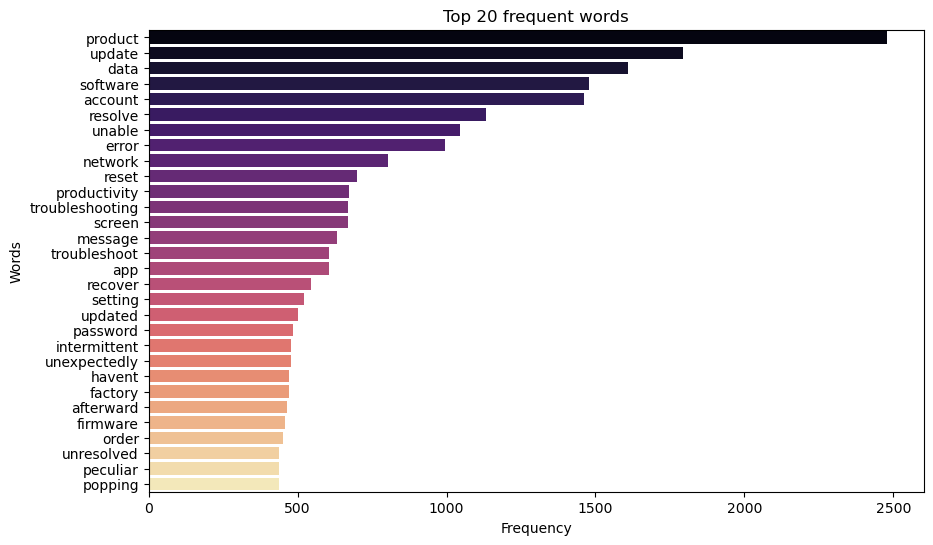

In [10]:
text_data = data_df['processed_text'].astype(str)

all_words = " ".join(text_data).lower().split()
common_words = Counter(all_words).most_common(30)

words, counts = zip(*common_words)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title("Top 20 frequent words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

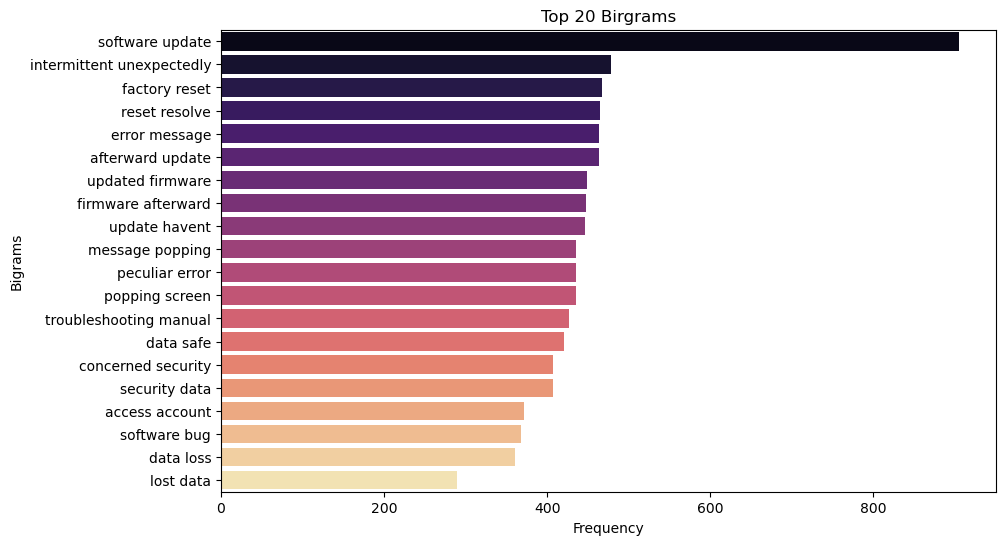

In [11]:
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
x = vectorizer.fit_transform(data_df['processed_text'])
word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma')
plt.title("Top 20 Birgrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.show()

In [12]:
ut.save_data(data_df, 'cleaned_data.csv')

Building the pipeline

In [13]:
def nlp_cleaner(text_list):
    results = []
    for text in text_list:
        cleaned = clean_text(text) 
        processed = preprocess(cleaned)
        results.append(processed)
    return results

### TFIDF

In [14]:
tfidf = TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7)

X = tfidf.fit_transform(data_df['processed_text'])

In [15]:
tfidf__preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner, validate=False)),
    ('tfidf', TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7))
])

### Embeddings

In [16]:
def clean_for_embeddings(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r"i'?m having an issue with.*?please assist\.?", ' ', text)
    text = re.sub(r'please assist\.?', ' ', text)
    text = re.sub(r'\b(id|created_at|product|price)\b', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [17]:
data_df['embedding_text'] = data_df['text'].apply(clean_for_embeddings)

In [18]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [19]:
embeddings = model.encode(data_df['embedding_text'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/253 [00:00<?, ?it/s]

In [20]:
embeddings = normalize(embeddings)

In [21]:
print(cosine_similarity([embeddings[0]], [embeddings[1]]))
print(cosine_similarity([embeddings[2]], [embeddings[5]]))

[[0.33734772]]
[[0.6662934]]


Building the pipeline

In [22]:
def nlp_cleaner_embeddings(text_list):
    results = []
    for text in text_list:
        cleaned = clean_for_embeddings(text) 
        results.append(cleaned)
    return results

In [23]:
embedding_preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner_embeddings, validate=False)),
    ('embeddings', md.SentenceEmbeddingTransformer(model_name='all-MiniLM-L6-v2')),
    ('normalize', Normalizer())
])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Modelling

## TF-IDF + HAC — Without Dimensionality Reduction (Yannan Li)

In this section, we apply Hierarchical Agglomerative Clustering (HAC) with **Ward linkage** directly to the TF-IDF sparse matrix (1 000-feature, (1,2)-gram). No dimensionality reduction is applied at this stage, so the clustering operates in the full 1 000-dimensional Euclidean space.

**Why Ward linkage?**  Ward linkage merges the two clusters that produce the smallest increase in total within-cluster variance. Compared with single or average linkage, it tends to produce more compact and balanced clusters, which is desirable when the goal is to surface distinct customer issue types.

**Known limitation — the curse of dimensionality.** In high-dimensional sparse spaces, Euclidean distances between points become nearly uniform, which can depress silhouette scores and make cluster boundaries less crisp. The PCA-reduced section that follows directly investigates whether this limitation can be mitigated.

| Setting | Value |
|---|---|
| Vectoriser | `TfidfVectorizer` |
| Features | 1 000 (`max_features=1000`) |
| N-gram range | (1, 2) |
| `min_df` / `max_df` | 5 / 0.70 |
| Linkage | Ward |
| Distance metric | Euclidean |

In [24]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import davies_bouldin_score
from sklearn.decomposition import PCA

### Step 1 — Dendrogram (sampled)

`scipy.linkage` requires a dense matrix and has O(n²) time and memory complexity, so we sample **300 tickets** purely for visualisation. All quantitative evaluations use the full dataset via `AgglomerativeClustering`.

The dendrogram shows how clusters merge as the Ward distance threshold increases. A large vertical gap between consecutive merges suggests a natural cut point — we mark the heuristic cut at 70 % of the maximum merge distance.

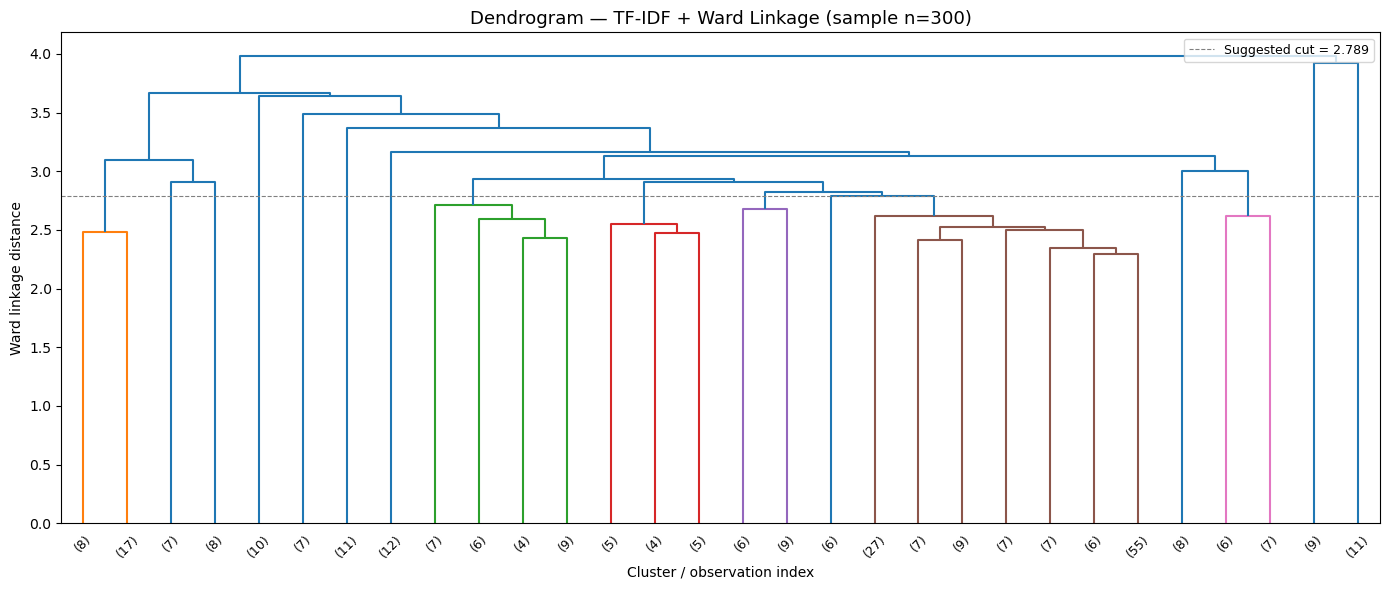

Suggested cut height: 2.789


In [25]:
SAMPLE_SIZE = 300
sample_df = data_df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
sample_X  = tfidf.transform(sample_df['processed_text']).toarray()

Z = linkage(sample_X, method='ward')
cut_height = 0.7 * max(Z[:, 2])

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=45,
    leaf_font_size=9,
    ax=ax,
    color_threshold=cut_height,
)
ax.axhline(y=cut_height, color='grey', linestyle='--', linewidth=0.8,
           label=f'Suggested cut = {cut_height:.3f}')
ax.set_title('Dendrogram — TF-IDF + Ward Linkage (sample n=300)', fontsize=13)
ax.set_xlabel('Cluster / observation index')
ax.set_ylabel('Ward linkage distance')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Suggested cut height: {round(cut_height, 3)}')

### Step 2 — Choose k: Silhouette & Davies-Bouldin across k = 2…10

We sweep k on the **full dataset** using two complementary metrics:

- **Silhouette score** (higher = better): measures how well each point fits its own cluster versus its nearest neighbour cluster.
- **Davies-Bouldin index** (lower = better): the average ratio of within-cluster scatter to between-cluster separation.

Ward linkage requires Euclidean distance, so both metrics are computed in the original Euclidean space (`X_dense`). Note that the Calinski-Harabasz score is deliberately omitted: it also assumes Euclidean distances and offers no additional information beyond Silhouette and Davies-Bouldin for our purposes.

Scanning k = 2 … 10 on full dataset ...
  k= 2  Silhouette = 0.0203  Davies-Bouldin = 1.4328
  k= 3  Silhouette = 0.0303  Davies-Bouldin = 1.4756
  k= 4  Silhouette = 0.0379  Davies-Bouldin = 3.0428
  k= 5  Silhouette = 0.0470  Davies-Bouldin = 3.0142
  k= 6  Silhouette = 0.0559  Davies-Bouldin = 2.9734
  k= 7  Silhouette = 0.0599  Davies-Bouldin = 2.8893
  k= 8  Silhouette = 0.0649  Davies-Bouldin = 2.9555
  k= 9  Silhouette = 0.0723  Davies-Bouldin = 2.7560
  k=10  Silhouette = 0.0773  Davies-Bouldin = 2.5852


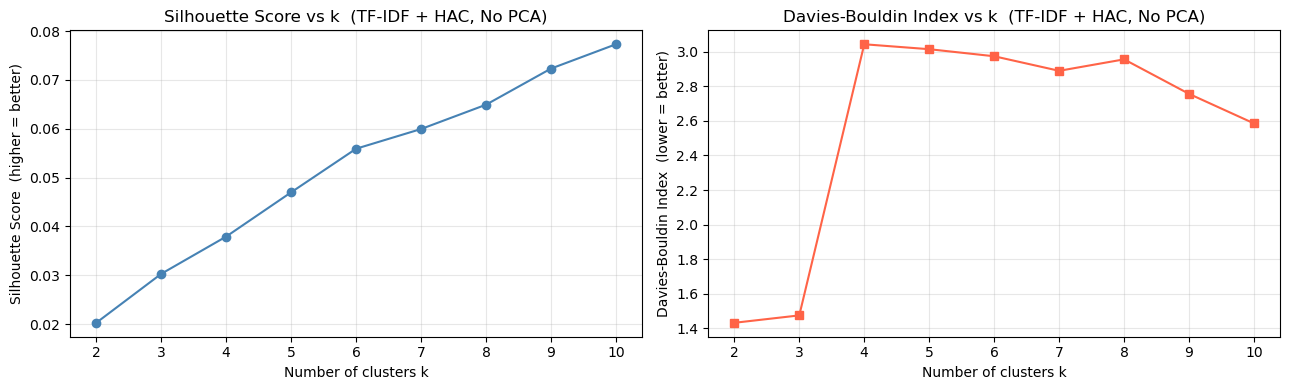


Best k by Silhouette:     10  (score = 0.0773)
Best k by Davies-Bouldin: 2  (score = 1.4328)


In [26]:
# Convert sparse matrix once — Ward linkage requires a dense array
X_dense = X.toarray()

k_range = range(2, 11)
sil_scores_hac = []
db_scores_hac  = []

print('Scanning k = 2 … 10 on full dataset ...')
for k in k_range:
    labels_tmp = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_dense)
    sil = silhouette_score(X_dense, labels_tmp)
    db  = davies_bouldin_score(X_dense, labels_tmp)
    sil_scores_hac.append(sil)
    db_scores_hac.append(db)
    print(f'  k={k:2d}  Silhouette = {sil:.4f}  Davies-Bouldin = {db:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), sil_scores_hac, marker='o', color='steelblue')
axes[0].set_title('Silhouette Score vs k  (TF-IDF + HAC, No PCA)')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Silhouette Score  (higher = better)')
axes[0].set_xticks(list(k_range))
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), db_scores_hac, marker='s', color='tomato')
axes[1].set_title('Davies-Bouldin Index vs k  (TF-IDF + HAC, No PCA)')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Davies-Bouldin Index  (lower = better)')
axes[1].set_xticks(list(k_range))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[sil_scores_hac.index(max(sil_scores_hac))]
best_k_db  = list(k_range)[db_scores_hac.index(min(db_scores_hac))]
print(f'\nBest k by Silhouette:     {best_k_sil}  (score = {max(sil_scores_hac):.4f})')
print(f'Best k by Davies-Bouldin: {best_k_db}  (score = {min(db_scores_hac):.4f})')

### Step 3 — Fit HAC for k = 3, 5, 7 (stability check)

We fit HAC at three candidate k values to assess stability. The k with the highest silhouette score among {3, 5, 7} is stored as `BEST_K` and written to `tfidf_hac_cluster`. Selecting `BEST_K` exclusively from this fitted set avoids a `KeyError` that would arise if the k-scan peak fell outside the candidate list.

In [27]:
HAC_K_VALUES = [3, 5, 7]

for k in HAC_K_VALUES:
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_dense)
    data_df[f'tfidf_hac_{k}'] = labels
    sil = silhouette_score(X_dense, labels)
    db  = davies_bouldin_score(X_dense, labels)
    print(f'k={k}  |  Silhouette = {sil:.4f}  |  Davies-Bouldin = {db:.4f}')

# Select BEST_K from fitted candidates only
sil_by_k = {
    k: silhouette_score(X_dense, data_df[f'tfidf_hac_{k}'].values)
    for k in HAC_K_VALUES
}
BEST_K = max(sil_by_k, key=sil_by_k.get)
data_df['tfidf_hac_cluster'] = data_df[f'tfidf_hac_{BEST_K}']

print(f'\nBest k among {HAC_K_VALUES}: {BEST_K}  '
      f'(Silhouette = {sil_by_k[BEST_K]:.4f})')
data_df[['processed_text', 'tfidf_hac_cluster']].head()

k=3  |  Silhouette = 0.0303  |  Davies-Bouldin = 1.4756
k=5  |  Silhouette = 0.0470  |  Davies-Bouldin = 3.0142
k=7  |  Silhouette = 0.0599  |  Davies-Bouldin = 2.8893

Best k among [3, 5, 7]: 7  (Silhouette = 0.0599)


,processed_text,tfidf_hac_cluster
0,billing zip code appreciate requested website ...,0
1,existing product intermittent unexpectedly,0
2,turning yesterday respond really charger came ...,0
3,youre interested love see feedback unresolved,0
4,seller responsible damage arising delivery bat...,0


### Step 4 — Cluster size distribution

Highly imbalanced cluster sizes (e.g. one cluster containing the vast majority of tickets) can indicate that Ward linkage is struggling to find compact natural groups in this high-dimensional space. We check all three k values side-by-side.

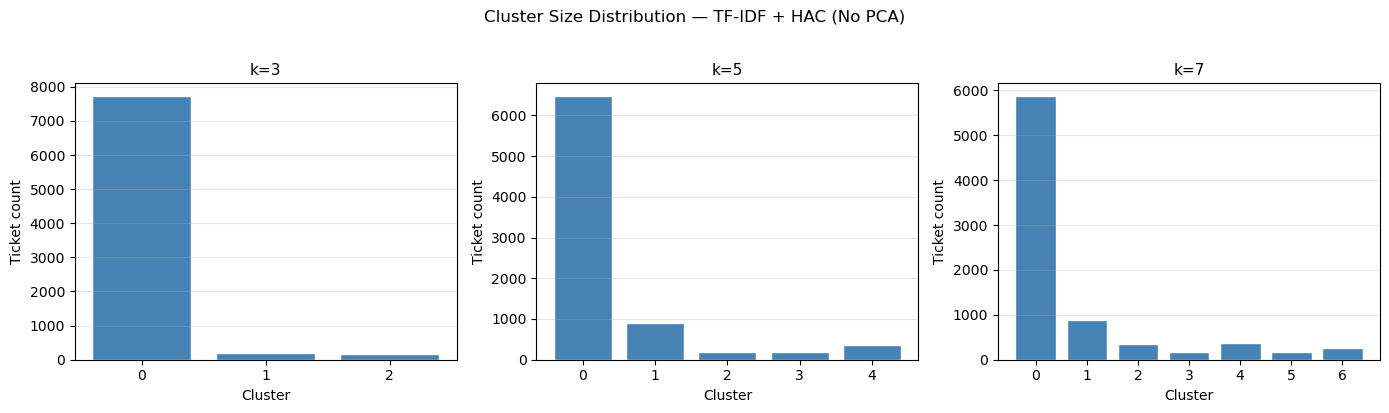

Cluster sizes (k=7):
tfidf_hac_cluster
0    5862
1     891
2     340
3     183
4     363
5     178
6     260
Name: count, dtype: int64


In [28]:
fig, axes = plt.subplots(1, len(HAC_K_VALUES), figsize=(14, 4), sharey=False)

for ax, k in zip(axes, HAC_K_VALUES):
    counts = data_df[f'tfidf_hac_{k}'].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color='steelblue', edgecolor='white')
    ax.set_title(f'k={k}', fontsize=11)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Ticket count')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Cluster Size Distribution — TF-IDF + HAC (No PCA)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'Cluster sizes (k={BEST_K}):')
print(data_df['tfidf_hac_cluster'].value_counts().sort_index())

### Step 5 — Top keywords per cluster (mean TF-IDF weight)

Unlike sentence embeddings, TF-IDF vectors have interpretable named dimensions (vocabulary terms). The mean TF-IDF weight per cluster identifies the most characteristic n-grams for each group, forming the primary evidence for manual labelling in Step 9.

In [29]:
terms = tfidf.get_feature_names_out()

def top_keywords(X_sparse, labels, cluster_id, n=10):
    mask = labels == cluster_id
    cluster_mean = np.asarray(X_sparse[mask].mean(axis=0)).ravel()
    top_idx = cluster_mean.argsort()[-n:][::-1]
    return [(terms[j], round(float(cluster_mean[j]), 4)) for j in top_idx]

print(f'=== Top keywords per cluster  (k={BEST_K}, TF-IDF + HAC, No PCA) ===')
for cid in sorted(data_df['tfidf_hac_cluster'].unique()):
    kws = top_keywords(X, data_df['tfidf_hac_cluster'].values, cid)
    print(f'\nCluster {cid}:')
    for word, score in kws:
        print(f'  {word:<30} {score}')

=== Top keywords per cluster  (k=7, TF-IDF + HAC, No PCA) ===

Cluster 0:
  product                        0.0549
  update                         0.0408
  software                       0.032
  productivity                   0.0264
  software update                0.0263
  unable                         0.0239
  troubleshooting                0.0232
  unresolved                     0.0213
  resolve                        0.0209
  unexpectedly                   0.0187

Cluster 1:
  data                           0.1827
  deleted                        0.0797
  safe                           0.0793
  data safe                      0.0791
  security data                  0.076
  concerned security             0.076
  concerned                      0.0758
  data loss                      0.0757
  loss                           0.0756
  security                       0.0755

Cluster 2:
  account                        0.3649
  password                       0.2489
  locked                 

### Step 6 — Word clouds per cluster

Word clouds provide a complementary visual overview of dominant vocabulary in each cluster. Together with the keyword table above, they support the manual labelling step.

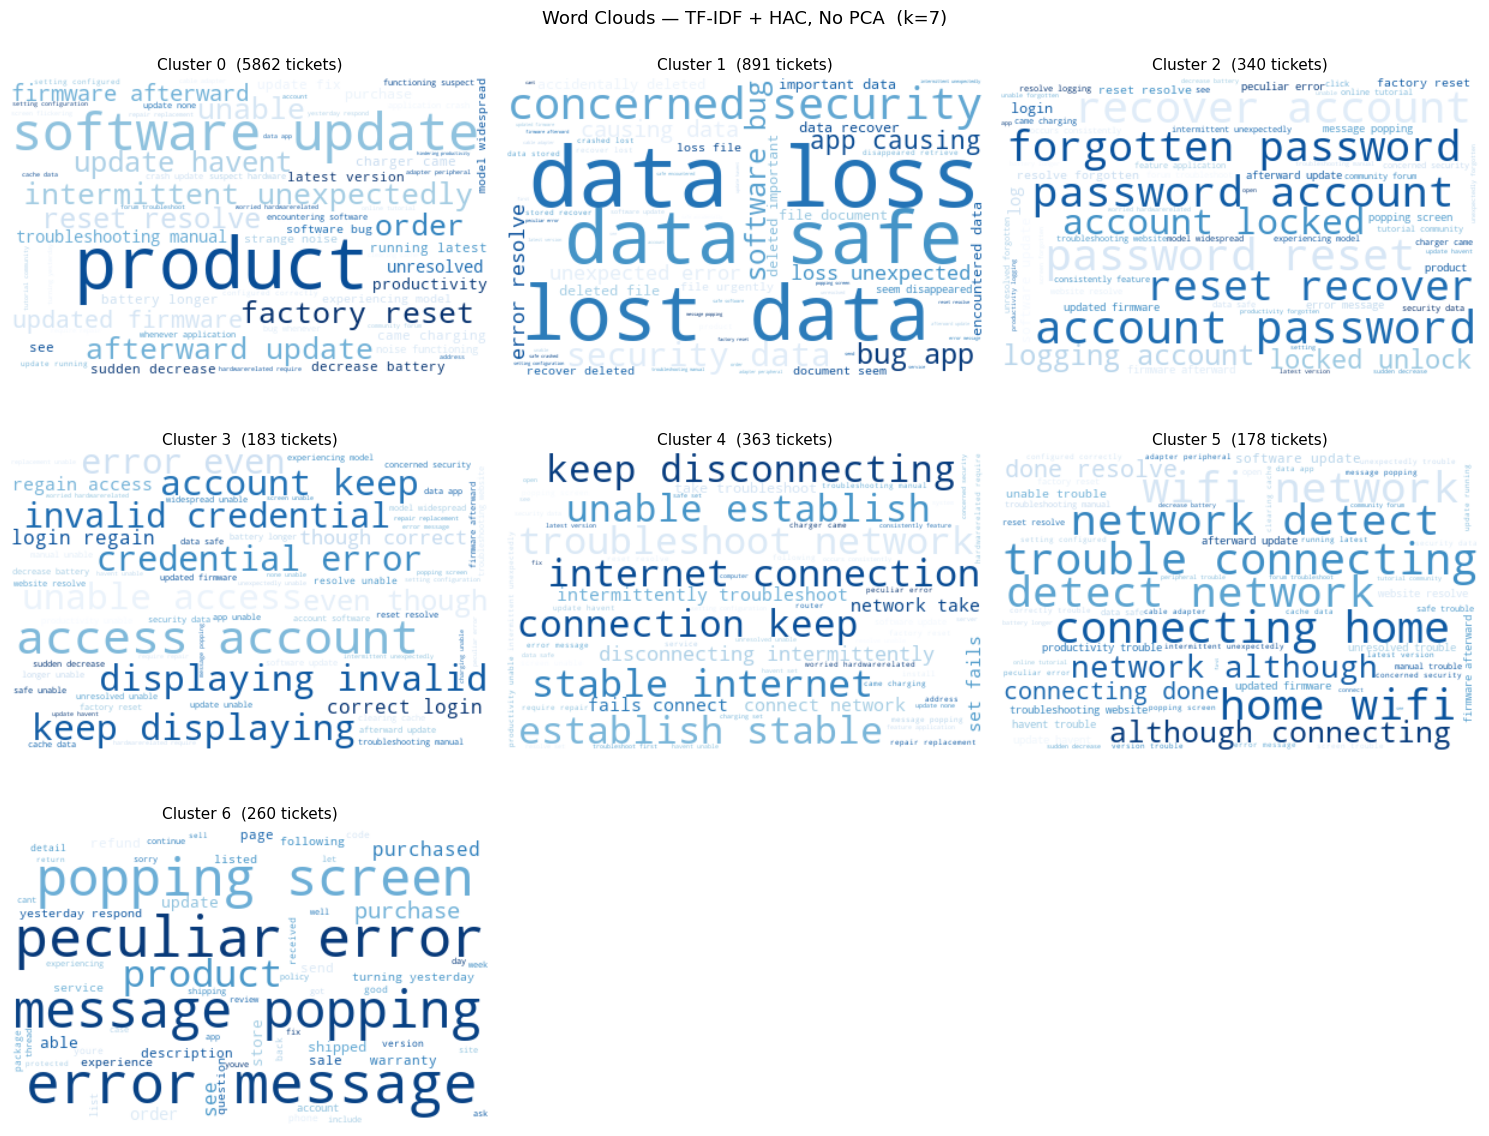

In [30]:
ncols = 3
nrows = (BEST_K + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for cid in range(BEST_K):
    mask = data_df['tfidf_hac_cluster'] == cid
    cluster_text = ' '.join(data_df.loc[mask, 'processed_text'].tolist())
    if not cluster_text.strip():
        axes[cid].set_visible(False)
        continue
    wc = WordCloud(width=400, height=250, background_color='white',
                   max_words=60, colormap='Blues').generate(cluster_text)
    axes[cid].imshow(wc, interpolation='bilinear')
    axes[cid].axis('off')
    axes[cid].set_title(f'Cluster {cid}  ({mask.sum()} tickets)', fontsize=11)

for j in range(BEST_K, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Word Clouds — TF-IDF + HAC, No PCA  (k={BEST_K})', fontsize=13)
plt.tight_layout()
plt.show()

### Step 7 — PCA 2D projection

We project the 1 000-dimensional TF-IDF space to 2D with PCA to visualise the cluster structure. Because the original space is very high-dimensional and sparse, the two principal components typically capture only a small fraction of total variance — this is expected and does not invalidate the clustering; it simply means 2D is a lossy view.

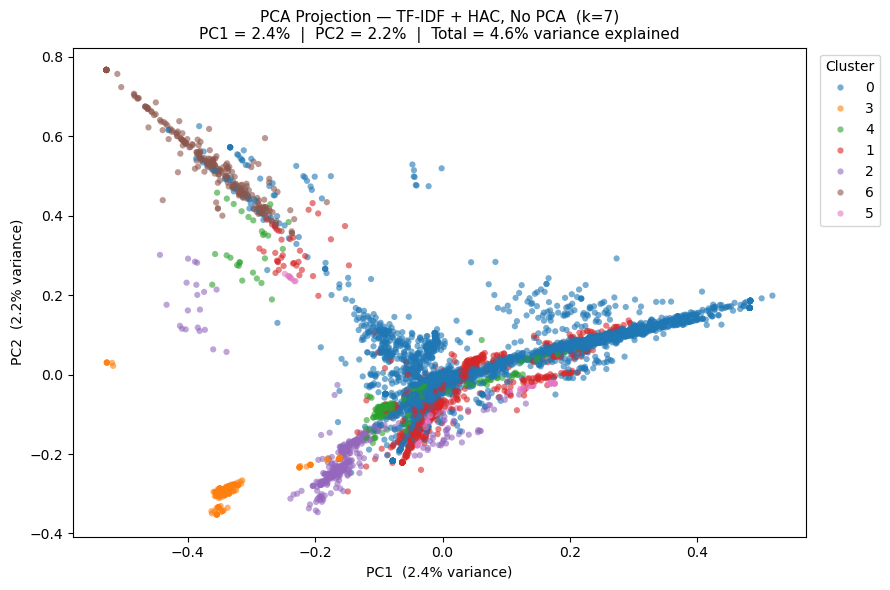

In [31]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_dense)
explained = pca_2d.explained_variance_ratio_

plot_df_hac = pd.DataFrame({
    'PC1': X_2d[:, 0],
    'PC2': X_2d[:, 1],
    'cluster': data_df['tfidf_hac_cluster'].astype(str)
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=plot_df_hac, x='PC1', y='PC2',
    hue='cluster', palette='tab10', s=20, alpha=0.6, linewidth=0
)
plt.title(
    f'PCA Projection — TF-IDF + HAC, No PCA  (k={BEST_K})\n'
    f'PC1 = {explained[0]*100:.1f}%  |  '
    f'PC2 = {explained[1]*100:.1f}%  |  '
    f'Total = {sum(explained)*100:.1f}% variance explained',
    fontsize=11
)
plt.xlabel(f'PC1  ({explained[0]*100:.1f}% variance)')
plt.ylabel(f'PC2  ({explained[1]*100:.1f}% variance)')
plt.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Step 8 — Stability summary across k = 3, 5, 7

If both metrics and cluster sizes remain broadly consistent across k values, the cluster structure is stable. Large metric swings suggest the TF-IDF space lacks a strong natural cluster structure at this granularity.

In [32]:
stability_rows = []
for k in HAC_K_VALUES:
    labels = data_df[f'tfidf_hac_{k}'].values
    sil = silhouette_score(X_dense, labels)
    db  = davies_bouldin_score(X_dense, labels)
    sizes = data_df[f'tfidf_hac_{k}'].value_counts().sort_index().tolist()
    stability_rows.append({
        'k':                             k,
        'Silhouette (higher=better)':    round(sil, 4),
        'Davies-Bouldin (lower=better)': round(db,  4),
        'Cluster sizes':                 str(sizes)
    })

stability_df = pd.DataFrame(stability_rows).set_index('k')
print('=== Stability Summary: TF-IDF + HAC (No PCA) ===')
print(stability_df.to_string())

=== Stability Summary: TF-IDF + HAC (No PCA) ===
   Silhouette (higher=better)  Davies-Bouldin (lower=better)                         Cluster sizes
k                                                                                                 
3                      0.0303                         1.4756                      [7716, 183, 178]
5                      0.0470                         3.0142            [6462, 891, 178, 183, 363]
7                      0.0599                         2.8893  [5862, 891, 340, 183, 363, 178, 260]


### Step 9 — Manual cluster labelling

After inspecting the keyword lists (Step 5) and word clouds (Step 6), assign a descriptive issue-type label to each cluster. **Update the dictionary below** once you have read the outputs.

In [33]:
# ── Update these labels after reading Steps 5 and 6 ──────────────────
# Example:
# topic_mapping_hac = {
#     0: 'Billing & payment issues',
#     1: 'Technical / app errors',
#     2: 'Delivery & logistics',
# }

topic_mapping_hac = {
    i: f'Cluster {i} — (to be labelled)' for i in range(BEST_K)
}

data_df['tfidf_hac_label'] = data_df['tfidf_hac_cluster'].map(topic_mapping_hac)

summary_hac = (
    data_df.groupby(['tfidf_hac_cluster', 'tfidf_hac_label'])
    .size().reset_index(name='ticket_count')
    .sort_values('tfidf_hac_cluster')
)
print(summary_hac.to_string(index=False))

 tfidf_hac_cluster              tfidf_hac_label  ticket_count
                 0 Cluster 0 — (to be labelled)          5862
                 1 Cluster 1 — (to be labelled)           891
                 2 Cluster 2 — (to be labelled)           340
                 3 Cluster 3 — (to be labelled)           183
                 4 Cluster 4 — (to be labelled)           363
                 5 Cluster 5 — (to be labelled)           178
                 6 Cluster 6 — (to be labelled)           260


## TF-IDF + HAC — With PCA Dimensionality Reduction (Yannan Li)

In this section we repeat the HAC analysis after projecting the TF-IDF matrix from **1 000 dimensions to 50 dimensions with Truncated SVD / PCA**. The goal is to assess whether removing low-variance noise dimensions improves cluster quality.

**Why PCA (TruncatedSVD) for TF-IDF?**

TF-IDF vectors are sparse — most entries are zero — and live in a high-dimensional Euclidean space. This creates two problems for HAC:

1. **Curse of dimensionality:** In high dimensions, all pairwise Euclidean distances converge to the same value, blurring cluster boundaries and depressing silhouette scores.
2. **Noise from rare terms:** Dimensions corresponding to infrequent or ambiguous terms add noise without contributing signal.

PCA (specifically `TruncatedSVD` for sparse matrices) projects the data onto the top-50 directions of maximum variance, compressing correlated term dimensions into latent semantic dimensions. This is related to **Latent Semantic Analysis (LSA)**, a classical NLP technique.

After reduction, the 50-dimensional dense vectors are used directly with Ward linkage and Euclidean distance — no re-normalisation is needed because Ward linkage is invariant to the absolute scale of the projected axes within the reduced space.

| Setting | Value |
|---|---|
| Vectoriser | `TfidfVectorizer` (same as before) |
| Reduction | `TruncatedSVD` → 50 components |
| Linkage | Ward |
| Distance metric | Euclidean (on reduced space) |

### Step 1 — TruncatedSVD Dimensionality Reduction

We apply `TruncatedSVD` (the sparse-matrix variant of PCA) to reduce from 1 000 to 50 dimensions. The cumulative explained variance ratio indicates how much of the original information is retained. Values above 50–60 % are generally considered sufficient for meaningful clustering.

TruncatedSVD: 1000D → 50D
Variance retained: 55.5%


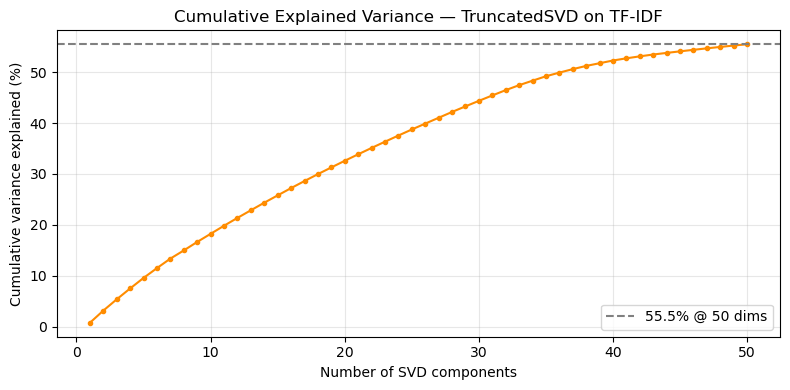

In [34]:
from sklearn.decomposition import TruncatedSVD

LSA_DIM = 50
svd = TruncatedSVD(n_components=LSA_DIM, random_state=42)
X_lsa = svd.fit_transform(X)   # X is the original sparse TF-IDF matrix

var_retained = svd.explained_variance_ratio_.sum()
print(f'TruncatedSVD: 1000D → {LSA_DIM}D')
print(f'Variance retained: {var_retained * 100:.1f}%')

# Cumulative explained variance plot
cumvar = np.cumsum(svd.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(range(1, LSA_DIM + 1), cumvar * 100, marker='o', markersize=3,
         color='darkorange')
plt.axhline(y=var_retained * 100, color='grey', linestyle='--',
            label=f'{var_retained*100:.1f}% @ {LSA_DIM} dims')
plt.title('Cumulative Explained Variance — TruncatedSVD on TF-IDF')
plt.xlabel('Number of SVD components')
plt.ylabel('Cumulative variance explained (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 2 — Dendrogram (sampled)

We rebuild the dendrogram on a 300-ticket sample of the LSA-reduced vectors. Comparing this dendrogram with the 1 000-dimensional version shows whether the merge-distance gaps are sharper after reduction — an indicator of better-separated clusters.

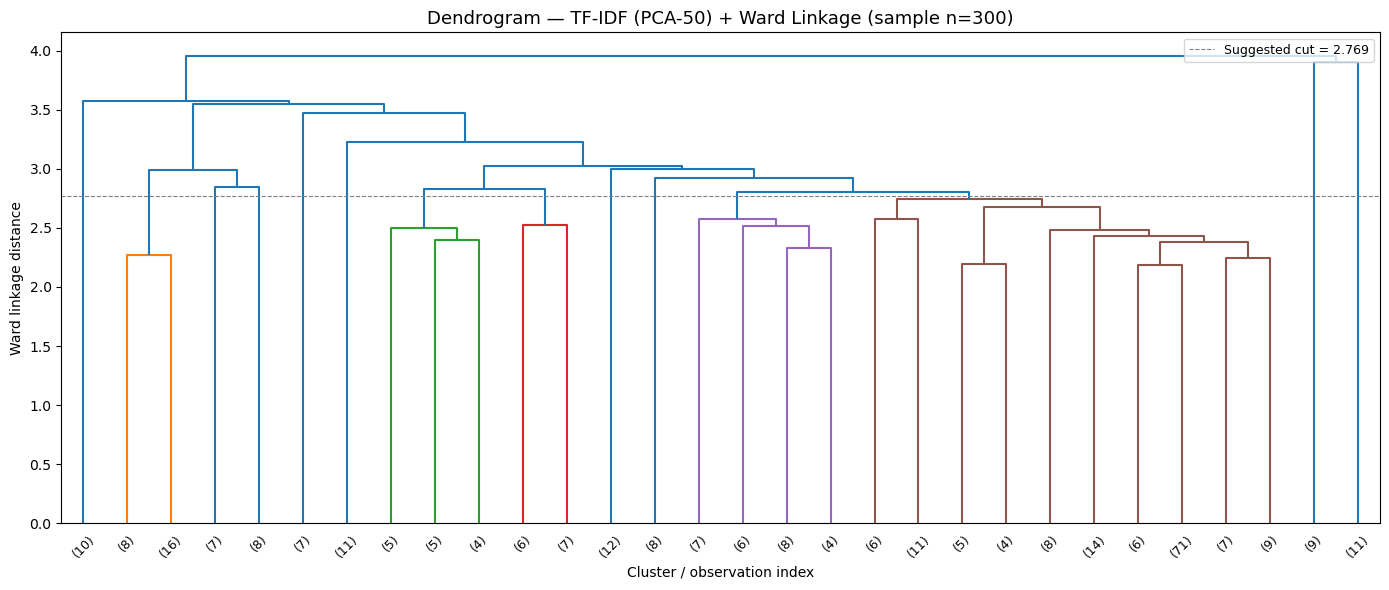

Suggested cut height (PCA-50): 2.769


In [35]:
SAMPLE_SIZE_LSA = 300
rng_lsa = np.random.RandomState(42)
sample_idx_lsa = rng_lsa.choice(len(X_lsa), size=SAMPLE_SIZE_LSA, replace=False)
sample_X_lsa = X_lsa[sample_idx_lsa]

Z_lsa = linkage(sample_X_lsa, method='ward')
cut_height_lsa = 0.7 * max(Z_lsa[:, 2])

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z_lsa,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=45,
    leaf_font_size=9,
    ax=ax,
    color_threshold=cut_height_lsa,
)
ax.axhline(y=cut_height_lsa, color='grey', linestyle='--', linewidth=0.8,
           label=f'Suggested cut = {cut_height_lsa:.3f}')
ax.set_title(
    f'Dendrogram — TF-IDF (PCA-{LSA_DIM}) + Ward Linkage (sample n={SAMPLE_SIZE_LSA})',
    fontsize=13
)
ax.set_xlabel('Cluster / observation index')
ax.set_ylabel('Ward linkage distance')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Suggested cut height (PCA-{LSA_DIM}): {round(cut_height_lsa, 3)}')

### Step 3 — Choose k: Silhouette & Davies-Bouldin across k = 2…10

We repeat the metric sweep on the full LSA-50 dataset. The 2×2 comparison plot below places the No-PCA and PCA-50 trajectories side by side, making it straightforward to see whether dimensionality reduction shifts the optimal k or improves the peak silhouette score.

Scanning k = 2 … 10 on TF-IDF PCA-50 ...
  k= 2  Silhouette = 0.1854  Davies-Bouldin = 1.0501
  k= 3  Silhouette = 0.1954  Davies-Bouldin = 1.0851
  k= 4  Silhouette = 0.0739  Davies-Bouldin = 2.3701
  k= 5  Silhouette = 0.0893  Davies-Bouldin = 2.5254
  k= 6  Silhouette = 0.1003  Davies-Bouldin = 2.3253
  k= 7  Silhouette = 0.1152  Davies-Bouldin = 2.1514
  k= 8  Silhouette = 0.1288  Davies-Bouldin = 2.1089
  k= 9  Silhouette = 0.1440  Davies-Bouldin = 2.0157
  k=10  Silhouette = 0.1475  Davies-Bouldin = 1.8850


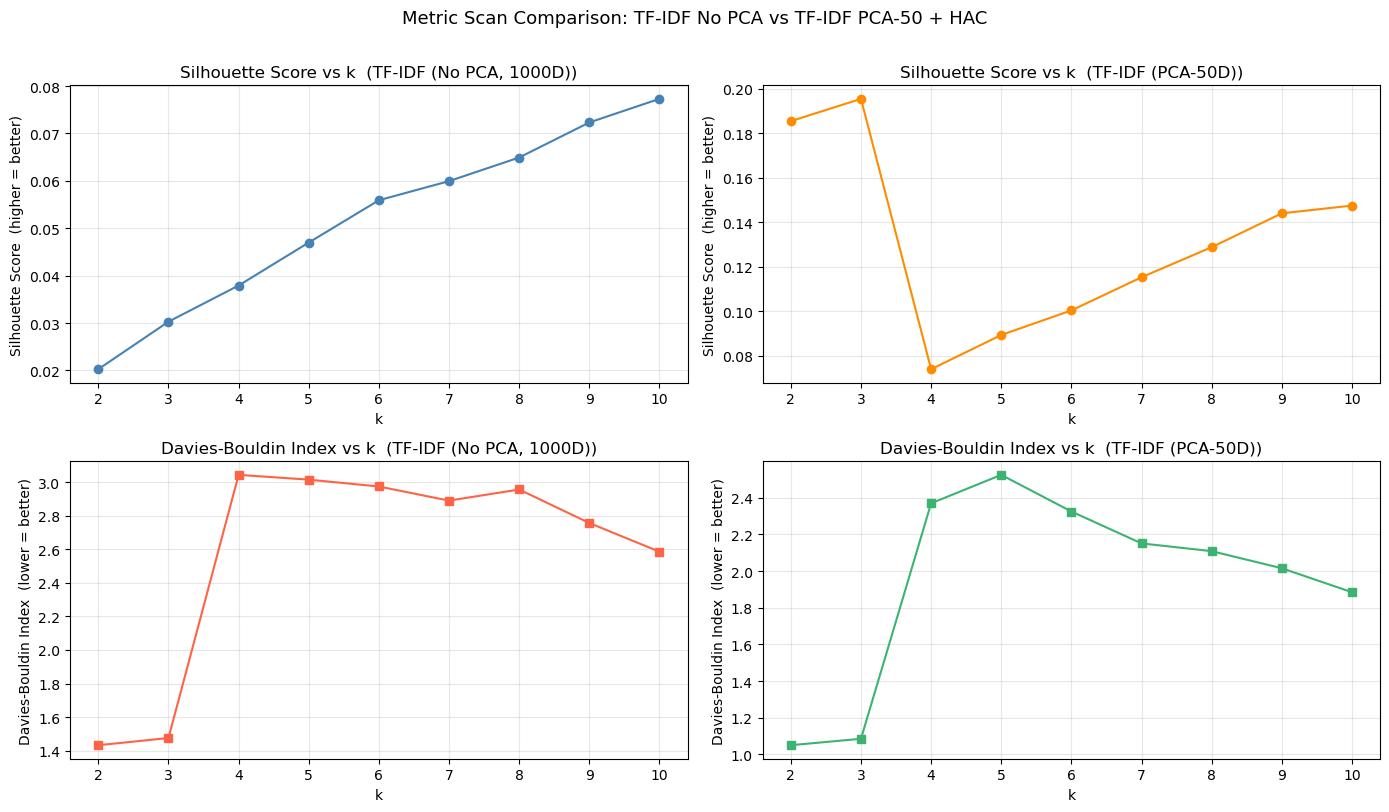


Best k by Silhouette  (PCA-50): 3  (score = 0.1954)
Best k by Davies-Bouldin (PCA-50): 2  (score = 1.0501)


In [36]:
sil_scores_lsa = []
db_scores_lsa  = []

print(f'Scanning k = 2 … 10 on TF-IDF PCA-{LSA_DIM} ...')
for k in k_range:
    labels_tmp = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_lsa)
    sil = silhouette_score(X_lsa, labels_tmp)
    db  = davies_bouldin_score(X_lsa, labels_tmp)
    sil_scores_lsa.append(sil)
    db_scores_lsa.append(db)
    print(f'  k={k:2d}  Silhouette = {sil:.4f}  Davies-Bouldin = {db:.4f}')

# ── 2×2 comparison plot ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

labels_cfg = ['TF-IDF (No PCA, 1000D)', f'TF-IDF (PCA-{LSA_DIM}D)']
sil_list   = [sil_scores_hac, sil_scores_lsa]
db_list    = [db_scores_hac,  db_scores_lsa]
colors     = [('steelblue', 'tomato'), ('darkorange', 'mediumseagreen')]

for col, (sil, db, lbl, (c1, c2)) in enumerate(
        zip(sil_list, db_list, labels_cfg, colors)):
    k_list = list(k_range)
    axes[0, col].plot(k_list, sil, marker='o', color=c1)
    axes[0, col].set_title(f'Silhouette Score vs k  ({lbl})')
    axes[0, col].set_xlabel('k')
    axes[0, col].set_ylabel('Silhouette Score  (higher = better)')
    axes[0, col].set_xticks(k_list)
    axes[0, col].grid(alpha=0.3)

    axes[1, col].plot(k_list, db, marker='s', color=c2)
    axes[1, col].set_title(f'Davies-Bouldin Index vs k  ({lbl})')
    axes[1, col].set_xlabel('k')
    axes[1, col].set_ylabel('Davies-Bouldin Index  (lower = better)')
    axes[1, col].set_xticks(k_list)
    axes[1, col].grid(alpha=0.3)

plt.suptitle(
    f'Metric Scan Comparison: TF-IDF No PCA vs TF-IDF PCA-{LSA_DIM} + HAC',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

best_k_sil_lsa = list(k_range)[sil_scores_lsa.index(max(sil_scores_lsa))]
best_k_db_lsa  = list(k_range)[db_scores_lsa.index(min(db_scores_lsa))]
print(f'\nBest k by Silhouette  (PCA-{LSA_DIM}): {best_k_sil_lsa}  '
      f'(score = {max(sil_scores_lsa):.4f})')
print(f'Best k by Davies-Bouldin (PCA-{LSA_DIM}): {best_k_db_lsa}  '
      f'(score = {min(db_scores_lsa):.4f})')

### Step 4 — Fit HAC for k = 3, 5, 7 (stability check)

We fit HAC on the LSA-50 vectors at the same three candidate k values for a direct comparison. `BEST_K_LSA` is selected from the fitted candidates only.

In [37]:
HAC_K_VALUES_LSA = [3, 5, 7]

for k in HAC_K_VALUES_LSA:
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_lsa)
    data_df[f'tfidf_lsa_hac_{k}'] = labels
    sil = silhouette_score(X_lsa, labels)
    db  = davies_bouldin_score(X_lsa, labels)
    print(f'k={k}  |  Silhouette = {sil:.4f}  |  Davies-Bouldin = {db:.4f}')

# Select BEST_K_LSA from fitted candidates only
sil_lsa_by_k = {
    k: silhouette_score(X_lsa, data_df[f'tfidf_lsa_hac_{k}'].values)
    for k in HAC_K_VALUES_LSA
}
BEST_K_LSA = max(sil_lsa_by_k, key=sil_lsa_by_k.get)
data_df['tfidf_lsa_hac_cluster'] = data_df[f'tfidf_lsa_hac_{BEST_K_LSA}']

print(f'\nBest k among {HAC_K_VALUES_LSA}: {BEST_K_LSA}  '
      f'(Silhouette = {sil_lsa_by_k[BEST_K_LSA]:.4f})')
data_df[['processed_text', 'tfidf_lsa_hac_cluster']].head()

k=3  |  Silhouette = 0.1954  |  Davies-Bouldin = 1.0851
k=5  |  Silhouette = 0.0893  |  Davies-Bouldin = 2.5254
k=7  |  Silhouette = 0.1152  |  Davies-Bouldin = 2.1514

Best k among [3, 5, 7]: 3  (Silhouette = 0.1954)


,processed_text,tfidf_lsa_hac_cluster
0,billing zip code appreciate requested website ...,0
1,existing product intermittent unexpectedly,0
2,turning yesterday respond really charger came ...,0
3,youre interested love see feedback unresolved,0
4,seller responsible damage arising delivery bat...,0


### Step 5 — Cluster size distribution

We check cluster balance across k = 3, 5, 7. After LSA reduction, Ward linkage operates in a denser, more uniformly distributed space — we expect cluster sizes to be somewhat more balanced than in the 1 000-dimensional case.

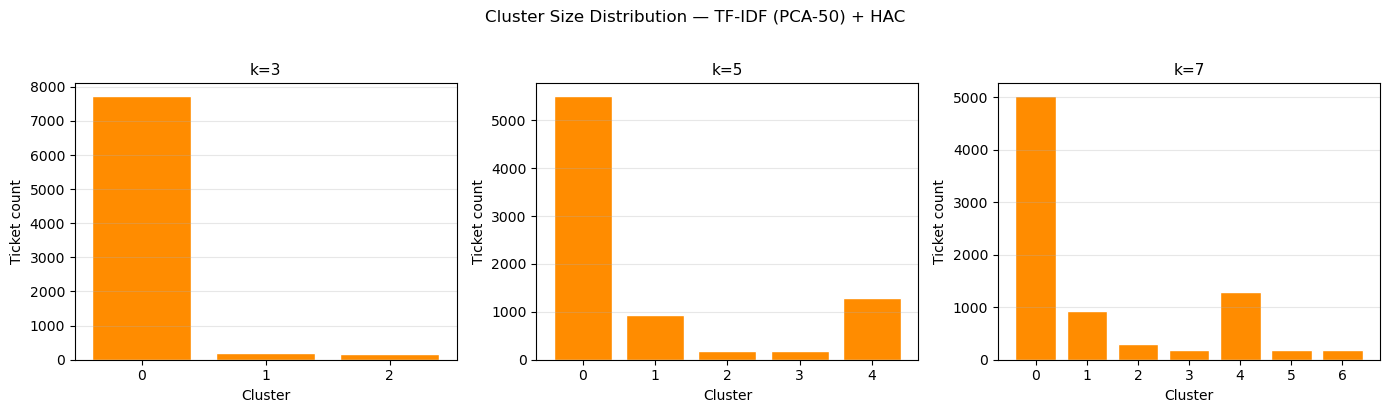

Cluster sizes (k=3):
tfidf_lsa_hac_cluster
0    7716
1     183
2     178
Name: count, dtype: int64


In [38]:
fig, axes = plt.subplots(1, len(HAC_K_VALUES_LSA), figsize=(14, 4), sharey=False)

for ax, k in zip(axes, HAC_K_VALUES_LSA):
    counts = data_df[f'tfidf_lsa_hac_{k}'].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color='darkorange', edgecolor='white')
    ax.set_title(f'k={k}', fontsize=11)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Ticket count')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    f'Cluster Size Distribution — TF-IDF (PCA-{LSA_DIM}) + HAC',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

print(f'Cluster sizes (k={BEST_K_LSA}):')
print(data_df['tfidf_lsa_hac_cluster'].value_counts().sort_index())

### Step 6 — Top keywords per cluster (mean TF-IDF weight)

Although the clustering was performed on the LSA-reduced vectors, we interpret each cluster using the **original TF-IDF vocabulary**. We project each cluster's centroid back to the original feature space by mapping the cluster assignments to the original sparse matrix `X`.

In [39]:
terms = tfidf.get_feature_names_out()

def top_keywords_lsa(X_sparse, lsa_labels, cluster_id, n=10):
    mask = lsa_labels == cluster_id
    cluster_mean = np.asarray(X_sparse[mask].mean(axis=0)).ravel()
    top_idx = cluster_mean.argsort()[-n:][::-1]
    return [(terms[j], round(float(cluster_mean[j]), 4)) for j in top_idx]

print(f'=== Top keywords per cluster  (k={BEST_K_LSA}, TF-IDF PCA-{LSA_DIM} + HAC) ===')
for cid in sorted(data_df['tfidf_lsa_hac_cluster'].unique()):
    kws = top_keywords_lsa(X, data_df['tfidf_lsa_hac_cluster'].values, cid)
    print(f'\nCluster {cid}:')
    for word, score in kws:
        print(f'  {word:<30} {score}')

=== Top keywords per cluster  (k=3, TF-IDF PCA-50 + HAC) ===

Cluster 0:
  product                        0.0466
  update                         0.035
  software                       0.0296
  data                           0.0287
  unable                         0.0228
  software update                0.0226
  productivity                   0.0223
  account                        0.0222
  resolve                        0.0218
  troubleshooting                0.0199

Cluster 1:
  access account                 0.3323
  access                         0.3216
  account                        0.2414
  regain                         0.1682
  displaying invalid             0.1673
  login regain                   0.1673
  invalid credential             0.1673
  displaying                     0.1673
  correct login                  0.1673
  though correct                 0.1673

Cluster 2:
  connecting                     0.3815
  network                        0.2954
  wifi                  

### Step 7 — Word clouds per cluster

Word clouds on the preprocessed text of each LSA cluster complement the keyword tables above. A colour scheme distinct from the No-PCA section (orange tones vs blue tones) makes it easy to distinguish results visually.

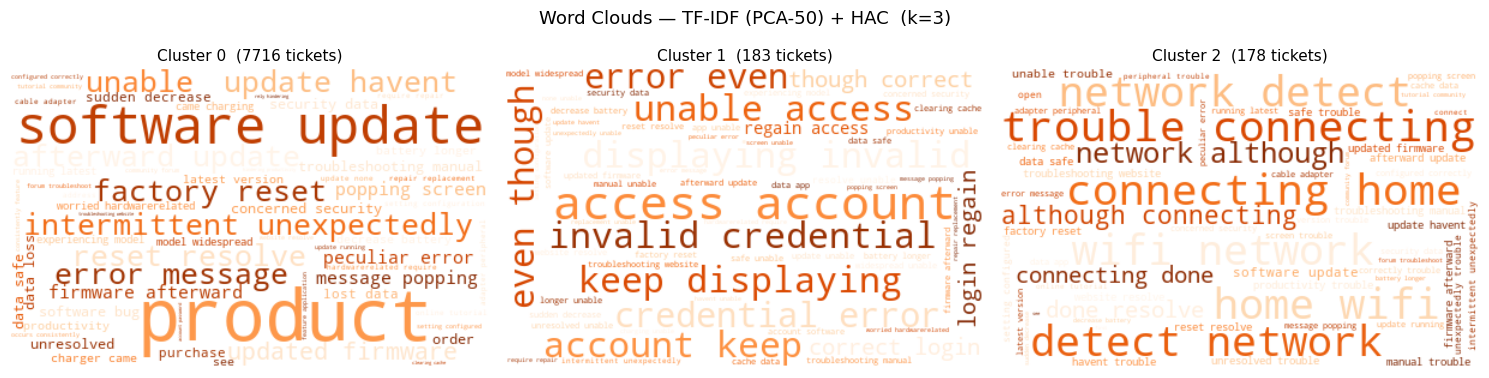

In [40]:
ncols_lsa = 3
nrows_lsa = (BEST_K_LSA + ncols_lsa - 1) // ncols_lsa

fig, axes = plt.subplots(nrows_lsa, ncols_lsa, figsize=(15, 4 * nrows_lsa))
axes = axes.flatten()

for cid in range(BEST_K_LSA):
    mask = data_df['tfidf_lsa_hac_cluster'] == cid
    cluster_text = ' '.join(data_df.loc[mask, 'processed_text'].tolist())
    if not cluster_text.strip():
        axes[cid].set_visible(False)
        continue
    wc = WordCloud(width=400, height=250, background_color='white',
                   max_words=60, colormap='Oranges').generate(cluster_text)
    axes[cid].imshow(wc, interpolation='bilinear')
    axes[cid].axis('off')
    axes[cid].set_title(f'Cluster {cid}  ({mask.sum()} tickets)', fontsize=11)

for j in range(BEST_K_LSA, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f'Word Clouds — TF-IDF (PCA-{LSA_DIM}) + HAC  (k={BEST_K_LSA})',
    fontsize=13
)
plt.tight_layout()
plt.show()

### Step 8 — PCA 2D projection

We project the LSA-50 vectors to 2D for visualisation. Because LSA already removes low-variance dimensions, the two PCA components are expected to capture a larger fraction of total variance than in the 1 000-dimensional case — giving a more faithful 2D view of the cluster structure.

The side-by-side plot uses the **same 2D PCA space** (fitted on the original 1 000-dimensional TF-IDF matrix) for both methods, so any visual difference in cluster shape reflects the clustering assignment rather than a change of projection axis.

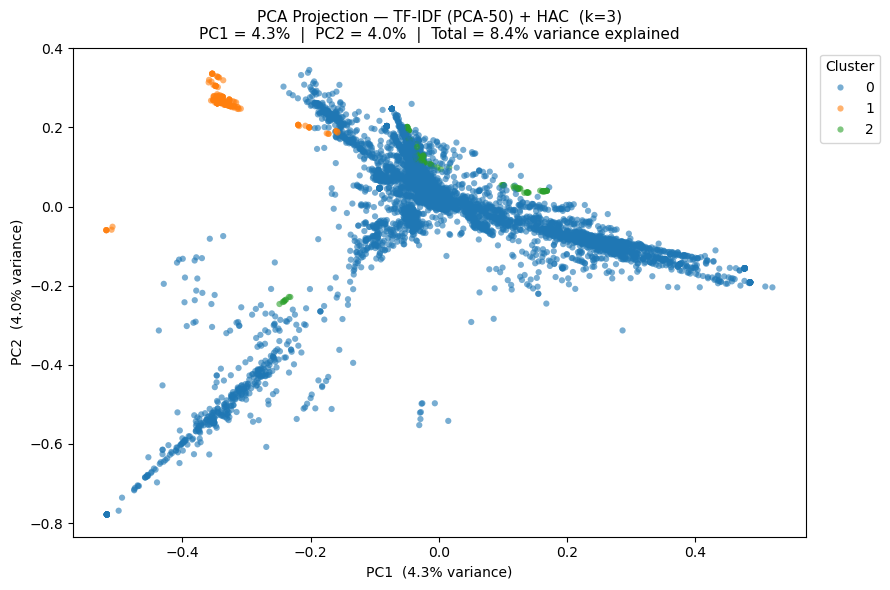

In [41]:
# ── Individual LSA-50 PCA scatter ─────────────────────────────────────
pca_vis_lsa = PCA(n_components=2, random_state=42)
X_lsa_2d = pca_vis_lsa.fit_transform(X_lsa)
exp_lsa = pca_vis_lsa.explained_variance_ratio_

df_lsa_2d = pd.DataFrame({
    'PC1': X_lsa_2d[:, 0],
    'PC2': X_lsa_2d[:, 1],
    'cluster': data_df['tfidf_lsa_hac_cluster'].astype(str)
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_lsa_2d, x='PC1', y='PC2',
    hue='cluster', palette='tab10', s=20, alpha=0.6, linewidth=0
)
plt.title(
    f'PCA Projection — TF-IDF (PCA-{LSA_DIM}) + HAC  (k={BEST_K_LSA})\n'
    f'PC1 = {exp_lsa[0]*100:.1f}%  |  '
    f'PC2 = {exp_lsa[1]*100:.1f}%  |  '
    f'Total = {sum(exp_lsa)*100:.1f}% variance explained',
    fontsize=11
)
plt.xlabel(f'PC1  ({exp_lsa[0]*100:.1f}% variance)')
plt.ylabel(f'PC2  ({exp_lsa[1]*100:.1f}% variance)')
plt.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Step 9 — Stability summary across k = 3, 5, 7

We compile the same stability metrics as Section A for a direct comparison. Consistent scores across k values indicate robust cluster structure in the LSA space.

In [42]:
stability_rows_lsa = []
for k in HAC_K_VALUES_LSA:
    labels = data_df[f'tfidf_lsa_hac_{k}'].values
    sil = silhouette_score(X_lsa, labels)
    db  = davies_bouldin_score(X_lsa, labels)
    sizes = data_df[f'tfidf_lsa_hac_{k}'].value_counts().sort_index().tolist()
    stability_rows_lsa.append({
        'k':                             k,
        'Silhouette (higher=better)':    round(sil, 4),
        'Davies-Bouldin (lower=better)': round(db,  4),
        'Cluster sizes':                 str(sizes)
    })

stability_lsa_df = pd.DataFrame(stability_rows_lsa).set_index('k')
print(f'=== Stability Summary: TF-IDF (PCA-{LSA_DIM}) + HAC ===')
print(stability_lsa_df.to_string())

=== Stability Summary: TF-IDF (PCA-50) + HAC ===
   Silhouette (higher=better)  Davies-Bouldin (lower=better)                          Cluster sizes
k                                                                                                  
3                      0.1954                         1.0851                       [7716, 183, 178]
5                      0.0893                         2.5254            [5497, 937, 178, 183, 1282]
7                      0.1152                         2.1514  [5014, 937, 300, 183, 1282, 178, 183]


### Step 10 — Manual cluster labelling

Assign descriptive labels after reviewing the keyword lists (Step 6) and word clouds (Step 7). **Update the dictionary below** once you have inspected the outputs.

In [43]:
# ── Update these labels after reading Steps 6 and 7 ──────────────────
# Example:
# topic_mapping_lsa = {
#     0: 'Billing & payment issues',
#     1: 'Technical / app errors',
#     2: 'Delivery & logistics',
# }

topic_mapping_lsa = {
    i: f'Cluster {i} — (to be labelled)' for i in range(BEST_K_LSA)
}

data_df['tfidf_lsa_hac_label'] = data_df['tfidf_lsa_hac_cluster'].map(topic_mapping_lsa)

summary_lsa = (
    data_df.groupby(['tfidf_lsa_hac_cluster', 'tfidf_lsa_hac_label'])
    .size().reset_index(name='ticket_count')
    .sort_values('tfidf_lsa_hac_cluster')
)
print(summary_lsa.to_string(index=False))

 tfidf_lsa_hac_cluster          tfidf_lsa_hac_label  ticket_count
                     0 Cluster 0 — (to be labelled)          7716
                     1 Cluster 1 — (to be labelled)           183
                     2 Cluster 2 — (to be labelled)           178


## Step 11 — Comparison: TF-IDF + HAC (No PCA) vs TF-IDF + HAC (PCA-50)

We consolidate the two TF-IDF + HAC variants into a single quantitative table and a side-by-side scatter plot.

**Interpreting the comparison:**

1. **Silhouette and Davies-Bouldin are directly comparable** between the two methods in this case, because both use Ward linkage with Euclidean distance — the PCA-50 vectors are still Euclidean and no re-normalisation is applied.
2. A higher silhouette score for PCA-50 indicates that removing low-variance term dimensions sharpened the Ward cluster boundaries. A similar or lower score would suggest the original 1 000-dimensional space already carries sufficient signal or that 50 components are too few.
3. The scatter plot projects both clustering assignments onto the **same 2D PCA space** (fitted on the original 1 000-dimensional TF-IDF matrix), so visual differences in cluster shape reflect changes in assignment rather than a different view angle.
4. Keyword interpretability is assessed qualitatively: if the PCA-50 clusters produce more semantically coherent keyword lists, that is a separate advantage not captured by the numeric metrics.

In [44]:
import warnings
warnings.filterwarnings('ignore')

comp_rows = []

# TF-IDF No PCA + HAC
for k in HAC_K_VALUES:
    lbl = data_df[f'tfidf_hac_{k}'].values
    sil = silhouette_score(X_dense, lbl)
    db  = davies_bouldin_score(X_dense, lbl)
    sizes = sorted(data_df[f'tfidf_hac_{k}'].value_counts().tolist(), reverse=True)
    comp_rows.append({
        'Method':                   'TF-IDF No PCA + HAC',
        'k':                        k,
        'Best k?':                  '✓' if k == BEST_K else '',
        'Silhouette ↑':             round(sil, 4),
        'Davies-Bouldin ↓':         round(db,  4),
        'Cluster sizes (desc)':     str(sizes),
    })

# TF-IDF PCA-50 + HAC
for k in HAC_K_VALUES_LSA:
    lbl = data_df[f'tfidf_lsa_hac_{k}'].values
    sil = silhouette_score(X_lsa, lbl)
    db  = davies_bouldin_score(X_lsa, lbl)
    sizes = sorted(data_df[f'tfidf_lsa_hac_{k}'].value_counts().tolist(), reverse=True)
    comp_rows.append({
        'Method':                   f'TF-IDF PCA-{LSA_DIM} + HAC',
        'k':                        k,
        'Best k?':                  '✓' if k == BEST_K_LSA else '',
        'Silhouette ↑':             round(sil, 4),
        'Davies-Bouldin ↓':         round(db,  4),
        'Cluster sizes (desc)':     str(sizes),
    })

comp_df = pd.DataFrame(comp_rows)
print('=== Final Comparison: TF-IDF No PCA vs PCA-50 + HAC ===')
print(comp_df.to_string(index=False))

=== Final Comparison: TF-IDF No PCA vs PCA-50 + HAC ===
             Method  k Best k?  Silhouette ↑  Davies-Bouldin ↓                  Cluster sizes (desc)
TF-IDF No PCA + HAC  3                0.0303            1.4756                      [7716, 183, 178]
TF-IDF No PCA + HAC  5                0.0470            3.0142            [6462, 891, 363, 183, 178]
TF-IDF No PCA + HAC  7       ✓        0.0599            2.8893  [5862, 891, 363, 340, 260, 183, 178]
TF-IDF PCA-50 + HAC  3       ✓        0.1954            1.0851                      [7716, 183, 178]
TF-IDF PCA-50 + HAC  5                0.0893            2.5254           [5497, 1282, 937, 183, 178]
TF-IDF PCA-50 + HAC  7                0.1152            2.1514 [5014, 1282, 937, 300, 183, 183, 178]


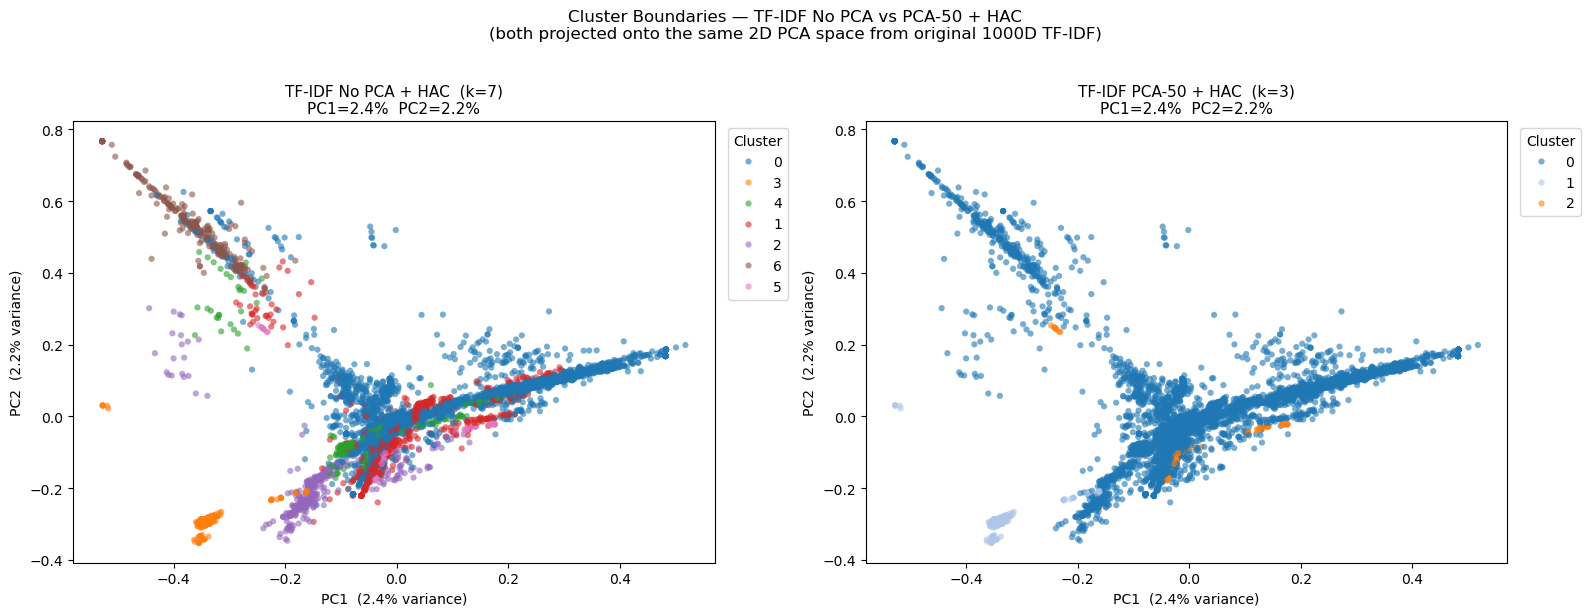

In [45]:
# ── Side-by-side PCA scatter: same 2D projection, different assignments ─
# Both projections use the 2D PCA fitted on the original 1000D TF-IDF matrix
pca_shared = PCA(n_components=2, random_state=42)
coords_shared = pca_shared.fit_transform(X_dense)
exp_shared = pca_shared.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_cfg = [
    ('tfidf_hac_cluster',     BEST_K,     'TF-IDF No PCA + HAC',          'tab10'),
    ('tfidf_lsa_hac_cluster', BEST_K_LSA, f'TF-IDF PCA-{LSA_DIM} + HAC',  'tab20'),
]

for ax, (col, bk, title, pal) in zip(axes, plot_cfg):
    df_plot = pd.DataFrame({
        'PC1': coords_shared[:, 0],
        'PC2': coords_shared[:, 1],
        'cluster': data_df[col].astype(str)
    })
    sns.scatterplot(
        data=df_plot, x='PC1', y='PC2',
        hue='cluster', palette=pal,
        s=20, alpha=0.6, linewidth=0, ax=ax
    )
    ax.set_title(
        f'{title}  (k={bk})\n'
        f'PC1={exp_shared[0]*100:.1f}%  '
        f'PC2={exp_shared[1]*100:.1f}%',
        fontsize=11
    )
    ax.set_xlabel(f'PC1  ({exp_shared[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2  ({exp_shared[1]*100:.1f}% variance)')
    ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle(
    f'Cluster Boundaries — TF-IDF No PCA vs PCA-{LSA_DIM} + HAC\n'
    '(both projected onto the same 2D PCA space from original 1000D TF-IDF)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()